### This dataset represents a direct marketing campaign of a bank where the goal is to predict whether a customer will subscribe to a term deposit based on demographic, financial, and past interaction data. It is a binary classification problem with class imbalance and some features like duration causing data leakage.

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\ML Model Implementations\12_Adaboost\Adaboost Classifier\bank.csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df_backup=df.copy()
df_backup.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


| Column Name   | Type      | Meaning                        | Example Values                          | Important Notes           |
| ------------- | --------- | ------------------------------ | --------------------------------------- | ------------------------- |
| **age**       | Numerical | Age of the client              | 25, 40, 60                              | Useful for segmentation   |
| **job**       | str       | Type of job                    | admin, technician, services, management | Needs encoding            |
| **marital**   | str       | Marital status                 | married, single, divorced               | Impacts decisions         |
| **education** | str       | Education level                | primary, secondary, tertiary            | Influences income         |
| **default**   | str       | Has credit in default?         | yes / no                                | Risk indicator            |
| **balance**   | Numerical | Yearly average balance (euros) | 1000, -200                              | Can be negative           |
| **housing**   | str       | Has housing loan?              | yes / no                                | Strong financial signal   |
| **loan**      | str       | Has personal loan?             | yes / no                                | Affects ability to invest |
| **contact**   | str       | Contact type                   | cellular, telephone                     | Marketing method          |
| **day**       | Numerical | Last contact day               | 1–31                                    | Weak alone                |
| **month**     | str       | Last contact month             | jan, feb, mar                           | Seasonal trends           |
| **duration**  | Numerical | Call duration (seconds)        | 120, 300                                | ⚠️ Leakage risk           |
| **campaign**  | Numerical | Contacts in campaign           | 1, 2, 5                                 | Too many → negative       |
| **pdays**     | Numerical | Days since last contact        | -1, 10                                  | -1 = never contacted      |
| **previous**  | Numerical | Previous contacts              | 0, 2                                    | Customer history          |
| **poutcome**  | str       | Previous campaign outcome      | success, failure                        | Strong feature            |
| **deposit**   | str       | Target (subscription)          | yes / no                                | 🎯 Target variable        |


## Data Understanding

In [6]:
df.shape

(11162, 17)

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [9]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

## EDA

## Univatiate Analysis 

### Count plot of numerical columns

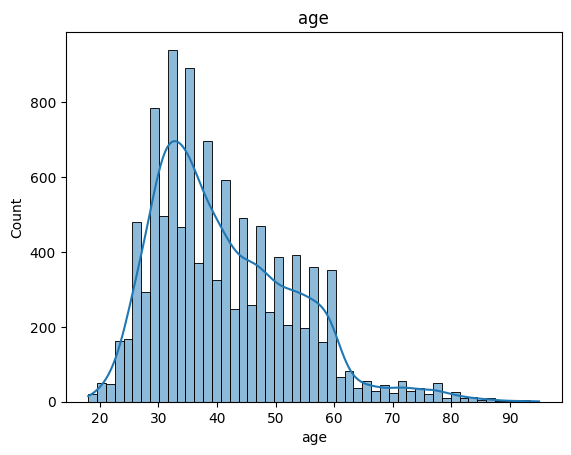

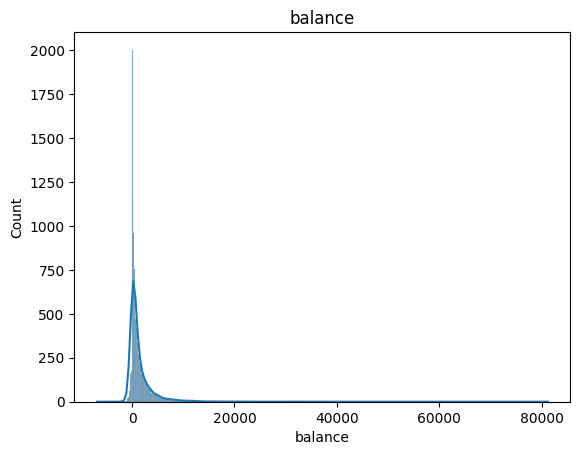

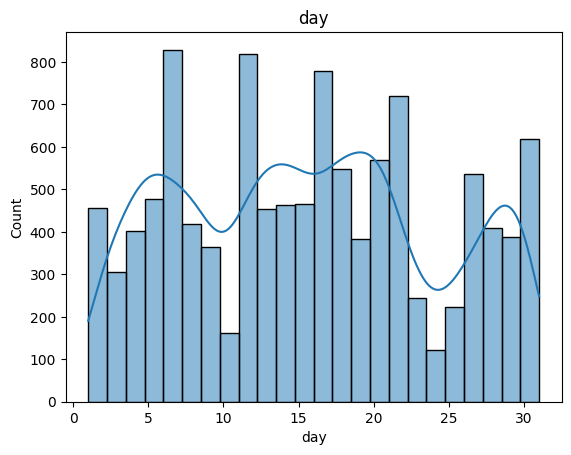

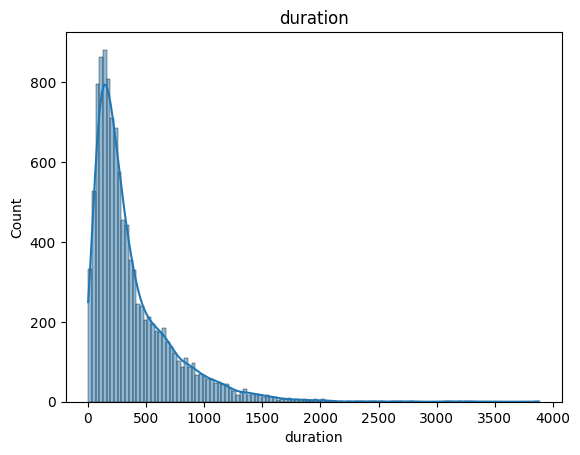

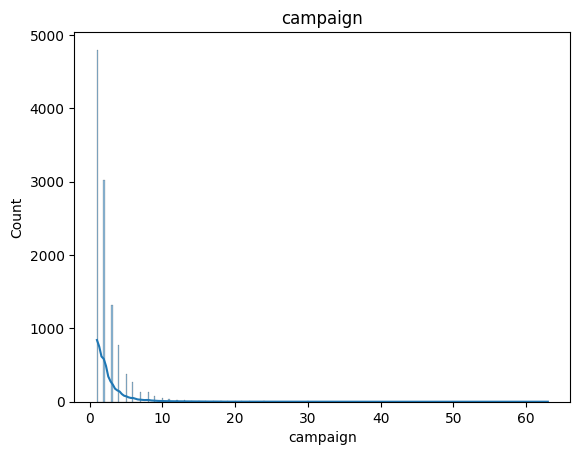

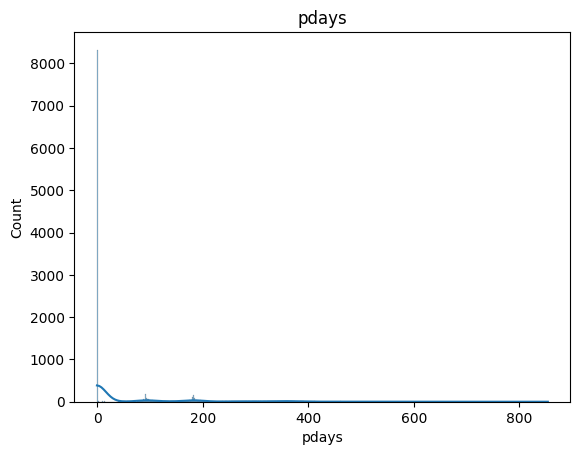

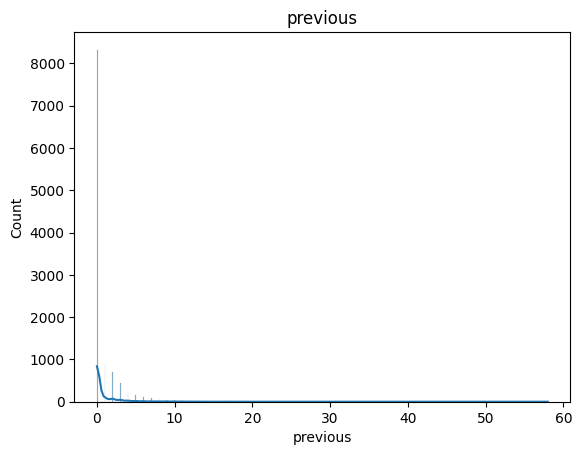

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age','balance','day','duration','campaign','pdays','previous']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Univariate Analysis Insights

## Age

* The distribution of age is slightly right-skewed.
* Most customers fall in the age group of **30 to 40 years**.
* There are fewer older customers (above 60), indicating a smaller senior population in the dataset.

---

## Balance

* The balance feature is **highly right-skewed** with extreme outliers.
* Most customers have a balance close to zero, while a few have very high balances.
* This indicates **financial inequality among customers** and presence of outliers.

---

## Duration

* The duration feature is strongly right-skewed.
* Most calls are short in duration, while a few calls are significantly longer.
* This feature is highly informative but leads to **data leakage**, as it is known only after the call ends.

---

## Campaign

* The campaign feature is right-skewed, with most customers contacted **1 to 3 times**.
* A small number of customers were contacted many times.
* This suggests that **excessive contact attempts are rare and may indicate low interest**.

---

## pdays

* The pdays feature shows a heavy concentration at lower values.
* A large number of customers were **never contacted before** (represented by special values like -1).
* The remaining values show a wide spread, indicating varied previous contact intervals.

---

## previous

* The previous feature is highly right-skewed.
* Most customers have **0 previous contacts**, meaning they are new customers.
* Only a few customers have been contacted multiple times in past campaigns.

---

## Day

* The day feature shows a relatively **uniform distribution** across the month.
* There is no strong skewness or dominant peak.
* This suggests that the day of contact does not have strong standalone predictive power.

---

## Overall Observations

* Several numerical features are **right-skewed with outliers**.
* Most customers have **low interaction history and moderate financial status**.
* Some features like **duration may introduce data leakage and should be handled carefully**.


### Count plot for categorical columns

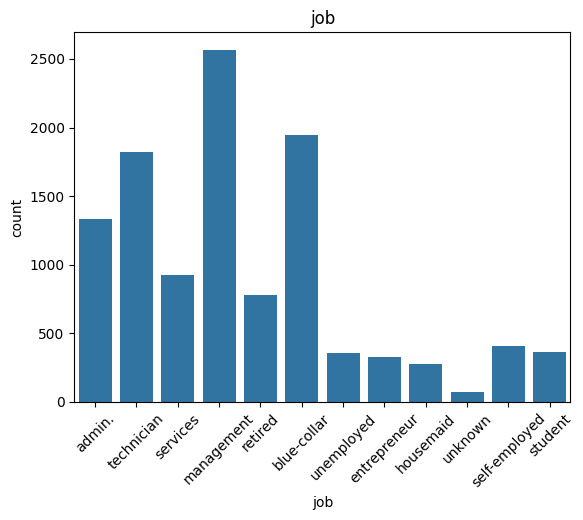

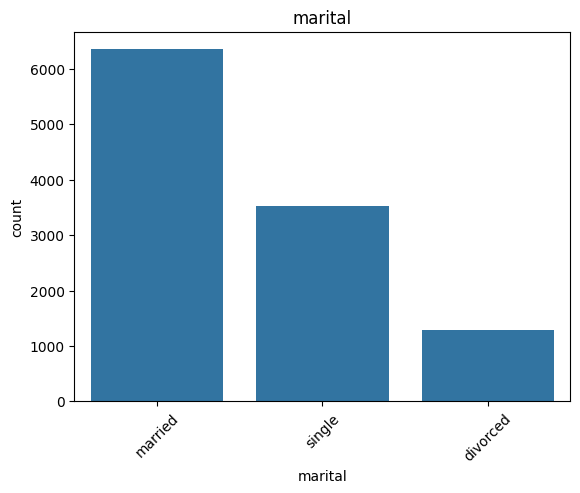

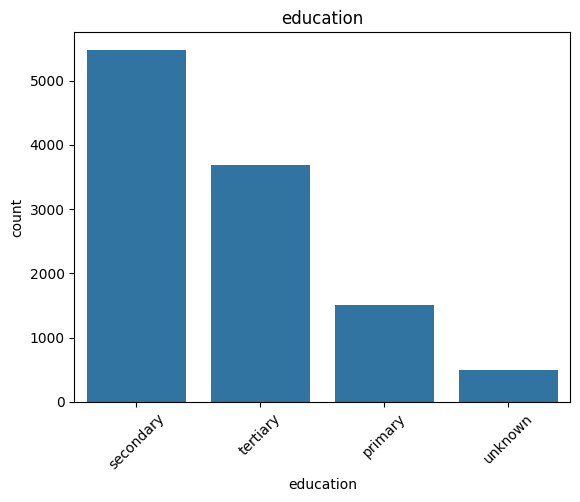

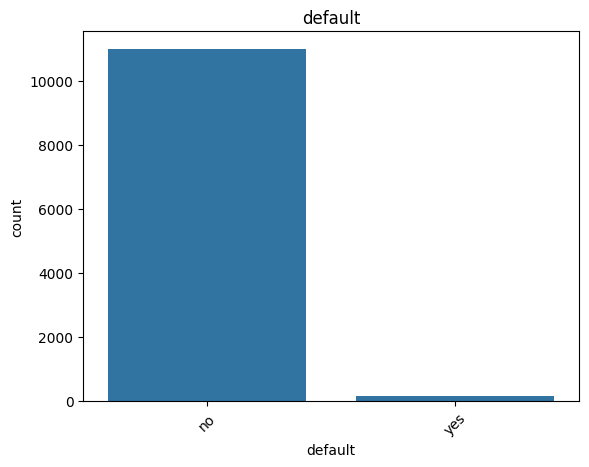

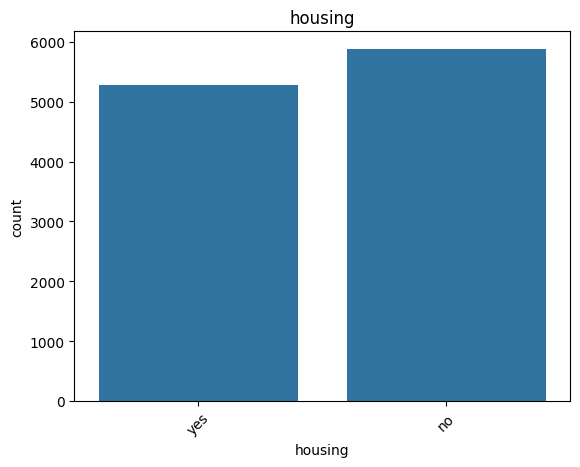

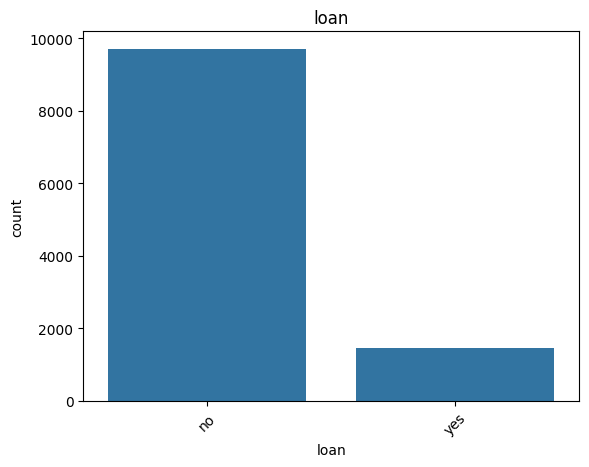

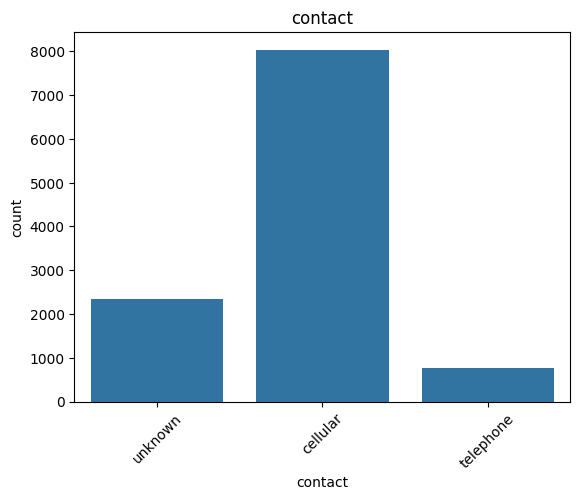

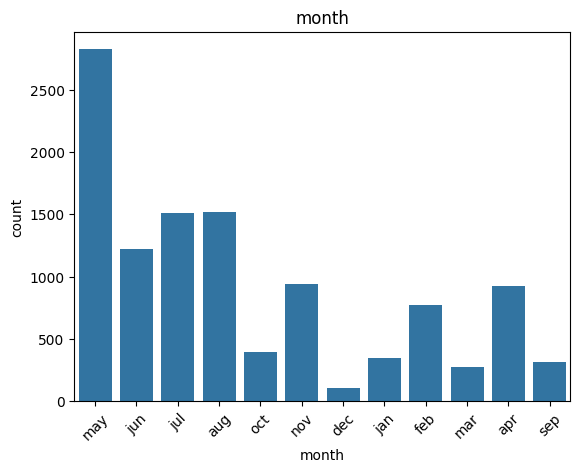

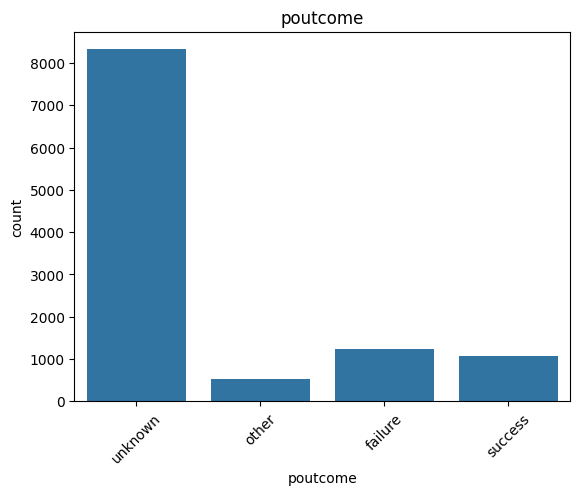

In [11]:
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

# Categorical Features Analysis

## Job

* The dataset contains a diverse set of job categories.
* The most frequent job types are management, blue-collar, and technician.
* Categories like unknown, student, and self-employed have relatively low counts.
* This indicates that the dataset is dominated by working professionals.

---

## Marital Status

* Most customers are married, followed by single, while divorced customers are the least.
* This suggests that a large portion of the dataset consists of individuals with family responsibilities.

---

## Education

* The majority of customers have secondary education, followed by tertiary education.
* A smaller number have primary education, and very few fall under unknown.
* This indicates a moderately educated customer base.

---

## Default

* Almost all customers have no credit default history.
* Very few customers fall into the default = yes category.
* This feature is highly imbalanced and may have limited predictive power.

---

## Housing Loan

* The number of customers with and without housing loans is relatively balanced.
* Slightly more customers do not have a housing loan.
* This feature may help differentiate financial commitments.

---

## Personal Loan

* A large majority of customers do not have a personal loan.
* Only a small portion of customers have loans.
* This indicates that most customers are not heavily burdened by personal debt.

---

## Contact Type

* Most contacts were made through cellular communication.
* A smaller number were through unknown, and very few through telephone.
* This reflects modern communication trends favoring mobile devices.

---

## Month

* Most contacts occurred during May, followed by July and August.
* Some months like December and January have very few contacts.
* This suggests seasonal trends in marketing campaigns.

---

## Previous Outcome (poutcome)

* A large portion of outcomes are unknown, indicating no previous campaign data.
* Among known outcomes, failure and success are present, with success being significant.
* This feature is highly informative for predicting customer behavior.

---

## Overall Observations

* Several categorical features show class imbalance, especially default and loan-related features.
* Features like job, education, and month provide useful segmentation information.
* poutcome and contact type are likely to be strong predictors.


#### Bivariate Analysis

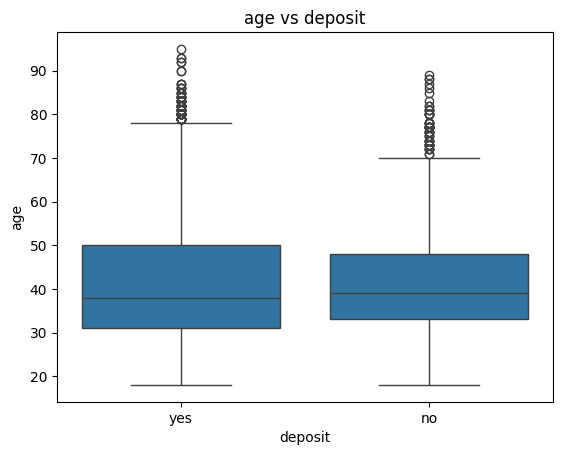

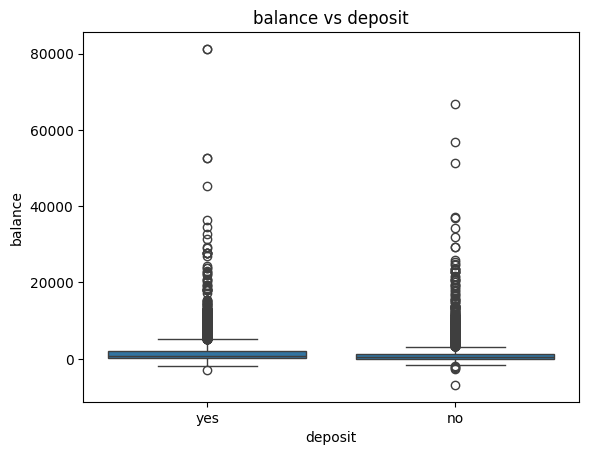

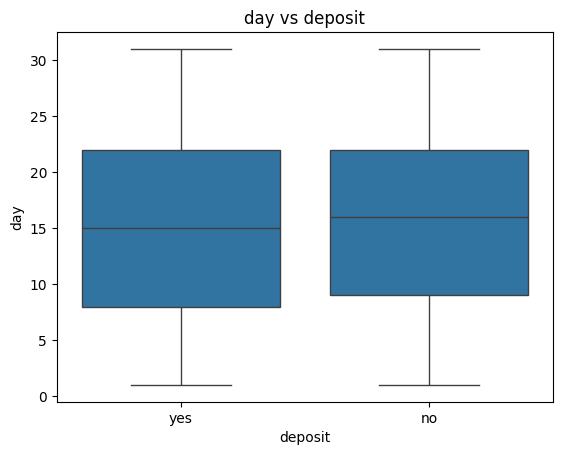

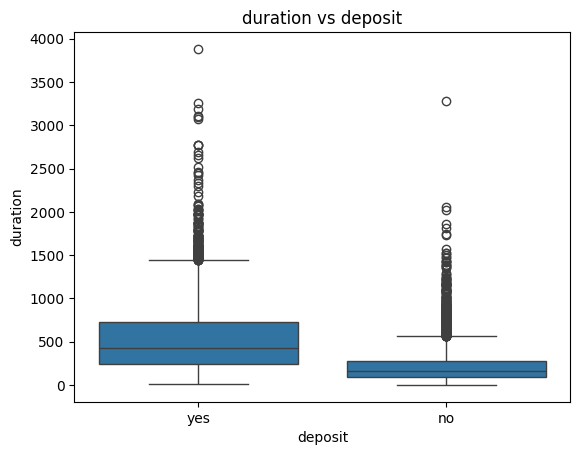

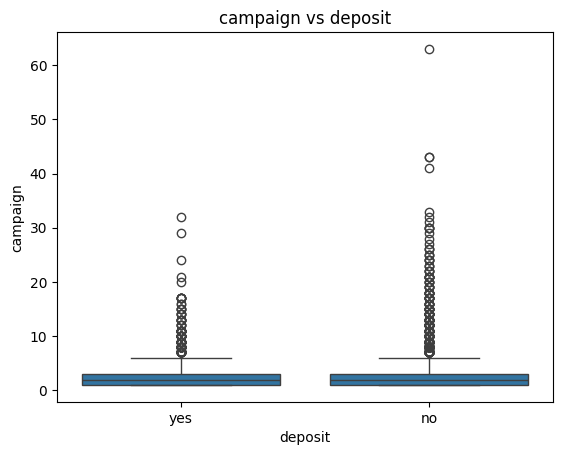

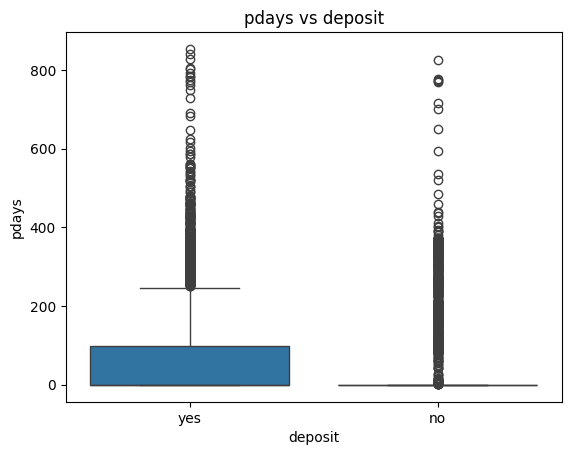

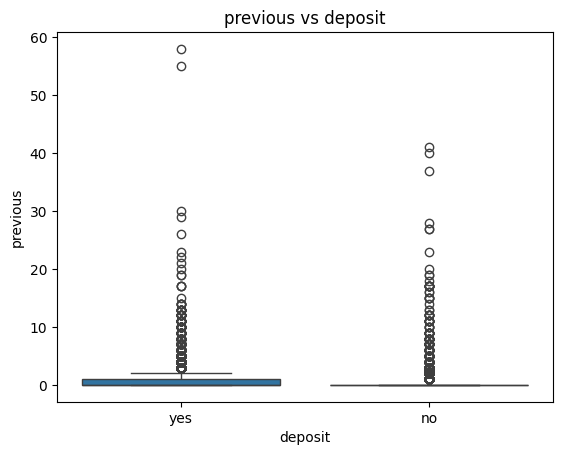

In [12]:
for col in num_cols:
    sns.boxplot(x=df['deposit'], y=df[col])
    plt.title(f"{col} vs deposit")
    plt.show()

# Bivariate Analysis (Numerical Features vs Target)

## Age vs Deposit

* The distribution of age is quite similar for both subscribed and non-subscribed customers.
* There is no significant difference in median age between the two groups.
* This suggests that age alone is not a strong predictor of subscription.

---

## Balance vs Deposit

* Customers who subscribed tend to have slightly higher account balances compared to those who did not.
* However, both groups contain significant outliers.
* Balance shows some predictive power but is not strongly separable.

---

## Day vs Deposit

* The distribution of the day of contact is very similar for both classes.
* There is no clear pattern indicating that a specific day influences subscription.
* This feature has low predictive importance.

---

## Duration vs Deposit

* Customers who subscribed have significantly higher call durations compared to those who did not.
* This is a strong separating feature between the two classes.
* However, this feature causes data leakage and should be removed before model training.

---

###### Campaign vs Deposit

* Customers who subscribed were generally contacted fewer times.
* Higher campaign values are more common among non-subscribed customers.
* This suggests that repeated contact may indicate lower interest.

---

## pdays vs Deposit

* Customers who subscribed tend to have lower pdays values.
* This indicates they were contacted more recently compared to non-subscribers.
* The feature provides moderate predictive information.

---

## Previous vs Deposit

* Most customers have zero previous contacts in both groups.
* However, slightly higher previous contacts are observed in subscribed customers.
* This feature alone has limited predictive power but may be useful when combined with other features.

---

## Overall Observations

* Duration is the most influential feature but must be removed due to data leakage.
* Campaign shows an inverse relationship with subscription likelihood.
* Balance and pdays provide moderate predictive signals.
* Age, day, and previous have relatively weak individual impact.
